Use o Pandas e a base de dados da aula para responder as seguintes questões:

Entrega: 4/12

In [1]:
import numpy as np
import pandas as pd
from pandas import Series, DataFrame
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline


vg = pd.read_csv('Video_Games_Sales_as_at_22_Dec_2016.csv')
vg.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8.0,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8.0,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
mv = pd.read_csv('Marvel_Movies_Dataset.csv')
mv.head()

,Index,Title,Director (1),Director (2),Release Date (DD-MM-YYYY),IMDb (scored out of 10),IMDB Metascore (scored out of 100),Rotten Tomatoes - Critics (scored out of 100%),Rotten Tomatoes - Audience (scored out of 100%),Letterboxd (scored out of 5),CinemaScore (grades A+ to F),Budget (in million $),Domestic Gross (in million $),Worldwide Gross (in million $)
0,0,Iron Man,Jon Favreau,NaN,2008-05-02 00:00:00,7.9,79,94,91,3.7,A,140.0,319.0,585.8
1,1,The Incredible Hulk,Louis Leterrier,NaN,2008-06-13 00:00:00,6.6,61,68,69,2.5,A-,150.0,134.8,265.5
2,2,Iron Man 2,Jon Favreau,NaN,2010-05-07 00:00:00,6.9,57,72,71,2.9,A,200.0,312.4,623.9
3,3,Thor,Kenneth Branagh,NaN,2011-05-06 00:00:00,7.0,57,77,76,2.8,B+,150.0,181.0,449.3
4,4,Captain America: The First Avenger,Joe Johnston,NaN,2011-07-22 00:00:00,6.9,66,80,75,3.3,A-,215.0,176.7,370.6


# Dataset 1

O mesmo da aula

Quais gêneros tem mais jogos?

<Axes: ylabel='Genre'>

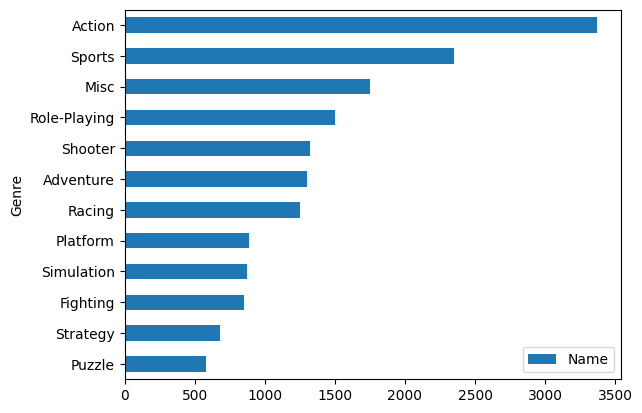

In [3]:
pivot1 = vg.pivot_table(values=["Name"], index=["Genre"], aggfunc='count').sort_values(by=['Name'], ascending=True)
pivot1.plot(kind='barh')

Quais anos tiveram mais lançamentos?

<Axes: xlabel='Year_of_Release'>

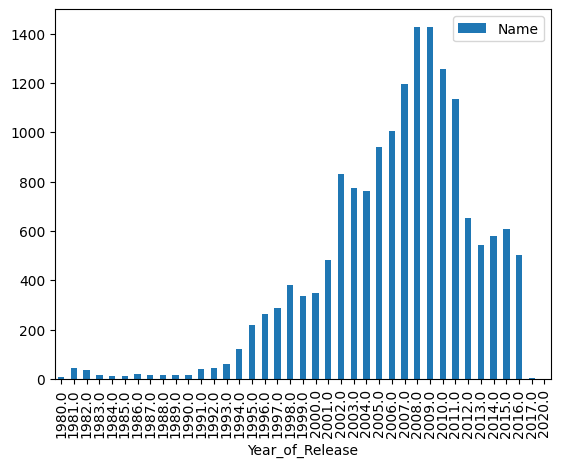

In [4]:
pivot2 = vg.pivot_table(values=["Name"], index=["Year_of_Release"], aggfunc='count')
pivot2.plot(kind='bar')

Os cinco anos com mais lançamentos, com estes lançamentos divididos por gênero

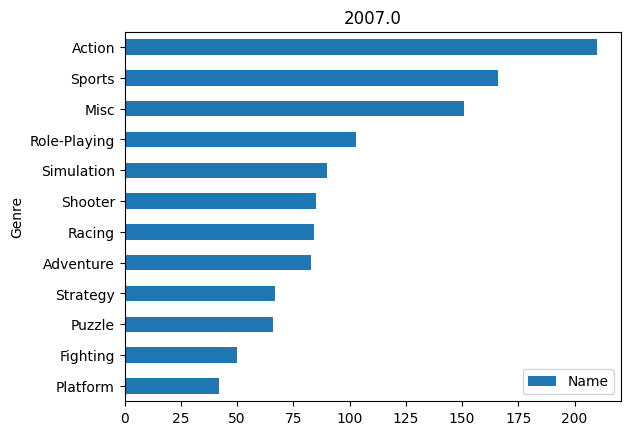

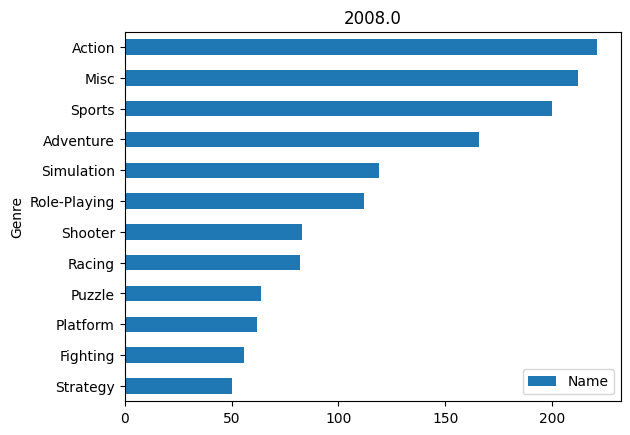

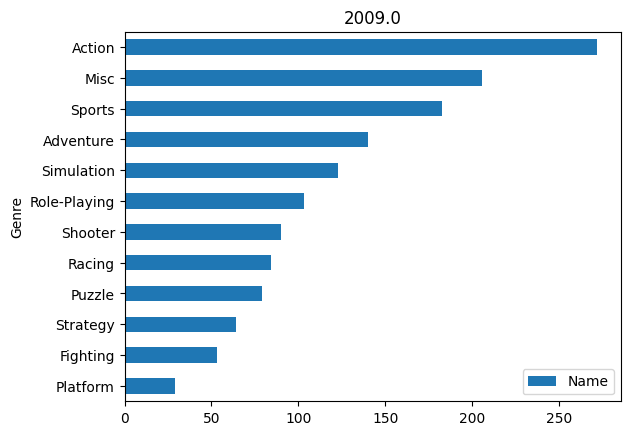

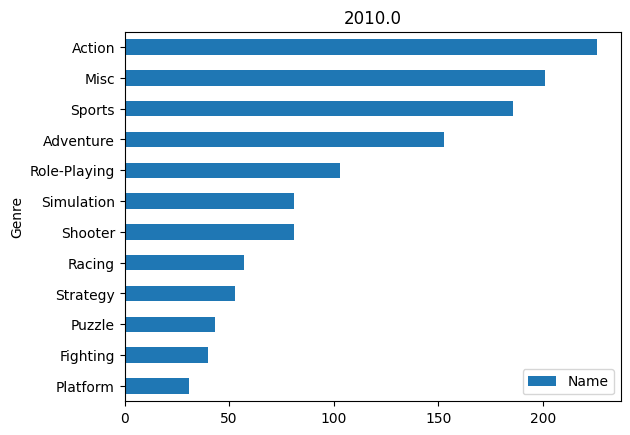

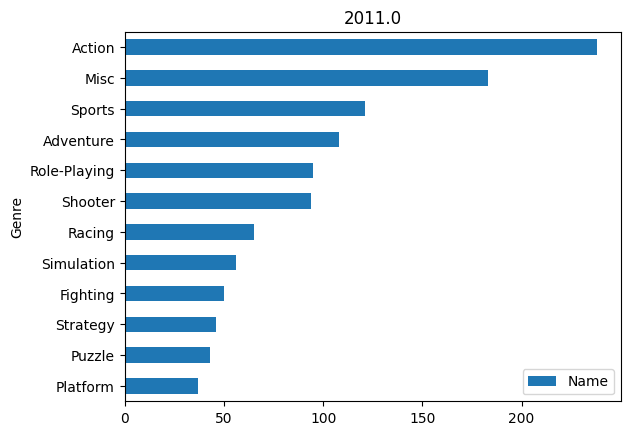

In [5]:
pivot3 = vg[vg["Year_of_Release"].isin(vg.pivot_table(values=["Name"], index=["Year_of_Release"], aggfunc='count').sort_values(by=['Name'], ascending=True).tail().index)]
pivot3 = pivot3.pivot_table(values=["Name"], index=["Year_of_Release", "Genre"], aggfunc='count').sort_values(by=['Name'], ascending=True)
#tabelas fora de ordem}
for year in pivot3.index.levels[0]:
    pivot3.loc[year].plot(kind='barh', title=year)

Faça um gráfico de anos por total de vendas globais.

<Axes: xlabel='Year_of_Release'>

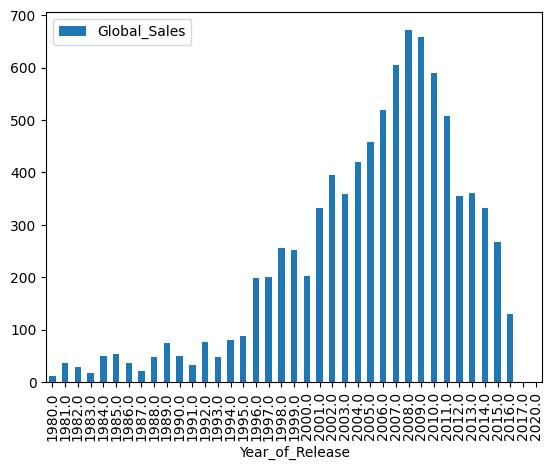

In [6]:
pivot4 = vg.pivot_table(values=["Global_Sales"], index=["Year_of_Release"], aggfunc='sum')
pivot4.plot(kind='bar')

Para cada ano, qual o gênero com mais lançamentos daquele ano.

In [7]:
# Chamando de pivot só pra manter o padrão
# Em caso de empates, apenas o primero gênero será considerado
# Esse não dá pra representar em um gráfico
pivot5 = vg.groupby(['Year_of_Release'], as_index=False).Genre.value_counts().groupby(['Year_of_Release'], as_index=False).first().drop(columns=['count'])
print(pivot5)

    Year_of_Release         Genre
0            1980.0          Misc
1            1981.0        Action
2            1982.0        Action
3            1983.0        Action
4            1984.0        Puzzle
5            1985.0      Platform
6            1986.0        Action
7            1987.0        Sports
8            1988.0      Platform
9            1989.0        Puzzle
10           1990.0        Action
11           1991.0        Sports
12           1992.0      Fighting
13           1993.0      Fighting
14           1994.0      Fighting
15           1995.0      Fighting
16           1996.0        Sports
17           1997.0        Sports
18           1998.0        Sports
19           1999.0        Sports
20           2000.0        Sports
21           2001.0        Sports
22           2002.0        Sports
23           2003.0        Action
24           2004.0        Action
25           2005.0        Action
26           2006.0        Action
27           2007.0        Action
28           2

Para cada ano, qual foi o gênero mais _vendido_ daquele ano

In [8]:
# Em caso de empates, apenas o primero gênero será considerado
# Esse não dá pra representar em um gráfico
pivot6 = vg.groupby(['Year_of_Release', 'Genre'], as_index=False).Global_Sales.sum().groupby(['Year_of_Release'], as_index=False).max().drop(columns=['Global_Sales'])
print(pivot6)

    Year_of_Release         Genre
0            1980.0        Sports
1            1981.0        Sports
2            1982.0        Sports
3            1983.0        Sports
4            1984.0        Sports
5            1985.0        Sports
6            1986.0        Sports
7            1987.0        Sports
8            1988.0        Sports
9            1989.0        Sports
10           1990.0        Sports
11           1991.0      Strategy
12           1992.0      Strategy
13           1993.0      Strategy
14           1994.0      Strategy
15           1995.0      Strategy
16           1996.0      Strategy
17           1997.0      Strategy
18           1998.0      Strategy
19           1999.0      Strategy
20           2000.0      Strategy
21           2001.0      Strategy
22           2002.0      Strategy
23           2003.0      Strategy
24           2004.0      Strategy
25           2005.0      Strategy
26           2006.0      Strategy
27           2007.0      Strategy
28           2

Faça uma tabela comparando, para cada gênero, as vendas globais, na américa do norte, europa e japão.

<Axes: ylabel='Genre'>

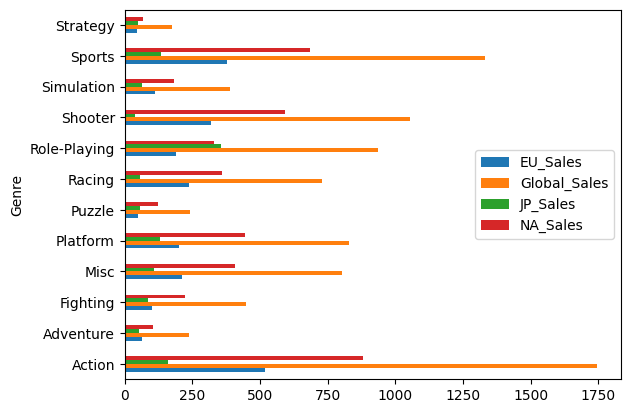

In [9]:
pivot7 = vg.pivot_table(values=["Global_Sales", "NA_Sales", "EU_Sales", "JP_Sales"], index=["Genre"], aggfunc="sum" )
pivot7.plot(kind='barh')

Faça um gráfico de vendas por publisher

<Axes: ylabel='Publisher'>

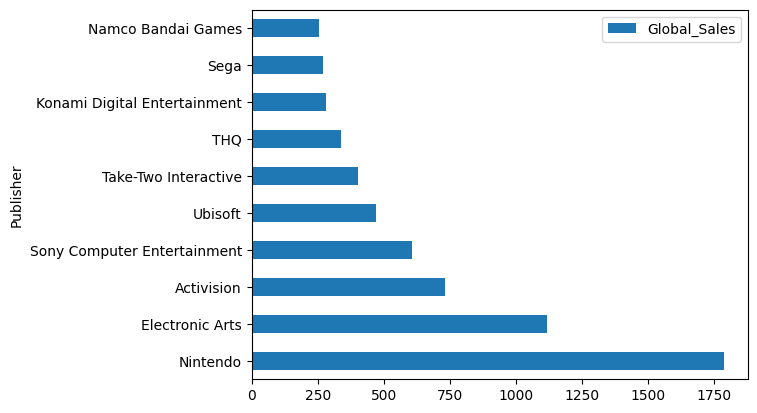

In [10]:
# Muitas publishers, o gráfico fica ilegível, usando head para mostrar apenas as 10 melhores
pivot8 = vg.pivot_table(values=["Global_Sales"], index=["Publisher"], aggfunc="sum" ).sort_values(by=['Global_Sales'], ascending=False).head(10)
pivot8.plot(kind='barh')

Faça uma tabela onde, para cada ano é listada a publisher com mais vendas globais naquele ano

In [11]:
pivot9 = vg.groupby(['Year_of_Release', 'Publisher'], as_index=False).Global_Sales.sum().groupby(['Year_of_Release'], as_index=False).max().drop(columns=['Global_Sales'])
print(pivot9)

    Year_of_Release               Publisher
0            1980.0                   Atari
1            1981.0                 Unknown
2            1982.0      Wizard Video Games
3            1983.0            Parker Bros.
4            1984.0                Nintendo
5            1985.0                Nintendo
6            1986.0                Nintendo
7            1987.0              SquareSoft
8            1988.0              SquareSoft
9            1989.0              SquareSoft
10           1990.0              SquareSoft
11           1991.0              Tecmo Koei
12           1992.0             id Software
13           1993.0      Victor Interactive
14           1994.0      Virgin Interactive
15           1995.0                 Yumedia
16           1996.0      Virgin Interactive
17           1997.0      Xing Entertainment
18           1998.0           Vivendi Games
19           1999.0        Westwood Studios
20           2000.0           Vivendi Games
21           2001.0             

# Dataset 2



Qual filme teve o maior orçamento?

In [12]:
# Há um empate
print(mv[mv["Budget (in million $)"] == mv["Budget (in million $)"].max()]["Title"])

18    Avengers: Infinity War
21         Avengers: Endgame
Name: Title, dtype: object


Qual é a média dos valores de IMDb para todos os filmes?

In [13]:
print(mv["IMDb (scored out of 10)"].mean())

7.2441176470588236


Quantos filmes possuem uma pontuação de Rotten Tomatoes - Critics maior que 80%?

In [14]:
print(len(mv[mv["Rotten Tomatoes - Critics (scored out of 100%)"] > 80]))

19


Quais diretores (diretor principal ou secundário) dirigiram mais de um filme no dataset?

In [15]:
directors = list(mv["Director (1)"]) + list(mv["Director (2)"])
print(len(set([d for d in directors if directors.count(d) > 1])))

10


Qual é a correlação entre o orçamento e o lucro bruto doméstico?

Nenhuma correlação, mas o gráfico abaixo mostra como eles se relaciocionam.


<Axes: xlabel='Budget (in million $)', ylabel='Domestic Gross (in million $)'>

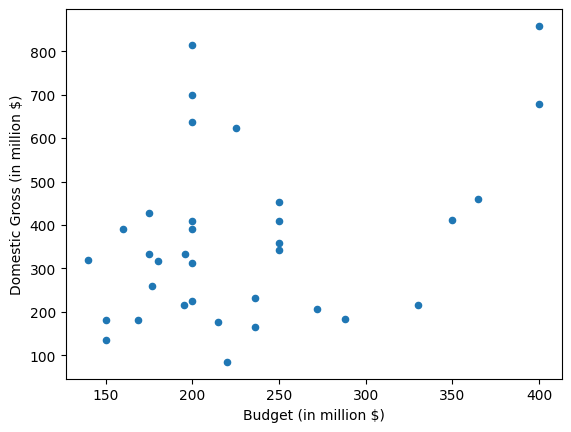

In [ ]:
mv.plot.scatter(x='Budget (in million $)', y='Domestic Gross (in million $)')

Quais filmes obtiveram um CinemaScore "A+"?

In [17]:
print(mv[mv["CinemaScore (grades A+ to F)"] == "A+"]["Title"])

5                The Avengers
17              Black Panther
21          Avengers: Endgame
26    Spider-Man: No Way Home
Name: Title, dtype: object


Qual foi o filme com a maior pontuação no Letterboxd?

In [18]:
# Empate
print(mv[mv["Letterboxd (scored out of 5)"] == mv["Letterboxd (scored out of 5)"].max()]["Title"])

18            Avengers: Infinity War
31    Guardians of the Galazy Vol. 3
Name: Title, dtype: object


Quantos filmes têm um lucro bruto mundial superior a 500 milhões de dólares?

In [19]:
print(mv[mv["Worldwide Gross (in million $)"] > 500]["Title"])

0                                        Iron Man
2                                      Iron Man 2
5                                    The Avengers
6                                      Iron Man 3
7                            Thor: The Dark World
8             Captain America: The Winter Soldier
9                         Guardians of the Galaxy
10                        Avengers: Age of Ultron
11                                        Ant-Man
12                     Captain America: Civil War
13                                 Doctor Strange
14                 Guardians of the Galaxy Vol. 2
15                         Spider-Man: Homecoming
16                                 Thor: Ragnarok
17                                  Black Panther
18                         Avengers: Infinity War
19                           Ant-Man and the Wasp
20                                 Captain Marvel
21                              Avengers: Endgame
22                      Spider-Man: Far From Home


Qual foi o filme mais bem avaliado em Rotten Tomatoes - Critics e Rotten Tomatoes - Audience juntos?

In [20]:
# Usando uma cópia para não alterar a original
mv2 = mv.copy(deep=True)
mv2["sum Rotten Tomatos"] = mv2["Rotten Tomatoes - Critics (scored out of 100%)"] + mv2["Rotten Tomatoes - Audience (scored out of 100%)"]
print(mv2[mv2["sum Rotten Tomatos"] == mv2["sum Rotten Tomatos"].max()]["Title"])

26    Spider-Man: No Way Home
Name: Title, dtype: object


Qual é a distribuição dos orçamentos dos filmes (mínimo, máximo, quartis)?

count     34.000000
mean     229.523529
std       69.004243
min      140.000000
25%      183.750000
50%      200.000000
75%      250.000000
max      400.000000
Name: Budget (in million $), dtype: float64

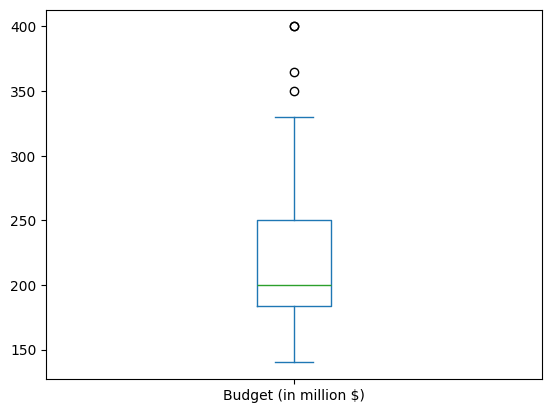

In [21]:
# Usando um boxplot para mostrar a distribuição
mv["Budget (in million $)"].plot(kind="box")
mv["Budget (in million $)"].describe()

Quais são os 5 filmes mais antigos no dataset?

In [22]:
mv.sort_values(by=["Release Date (DD-MM-YYYY)"])["Title"].head()

0                              Iron Man
1                   The Incredible Hulk
2                            Iron Man 2
3                                  Thor
4    Captain America: The First Avenger
Name: Title, dtype: object

Qual é a relação entre o IMDb Metascore e o Rotten Tomatoes - Critics?

Essas notas são feitas por profissionais que tem mentalidade semelhante e filmes melhores costumam ter notas melhores, portanto os valores devem ser parecidos


<Axes: xlabel='IMDB Metascore (scored out of 100)', ylabel='Rotten Tomatoes - Critics (scored out of 100%)'>

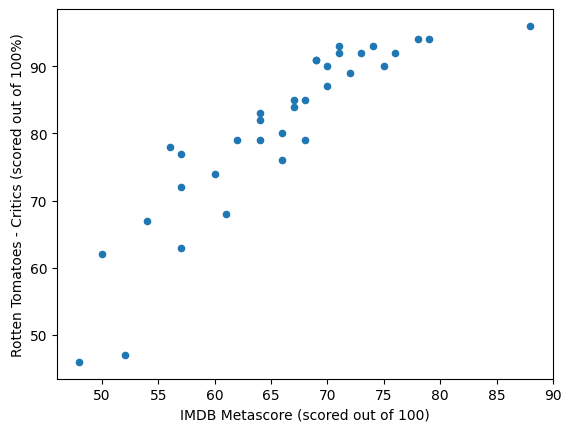

In [ ]:
mv.plot.scatter(x="IMDB Metascore (scored out of 100)", y="Rotten Tomatoes - Critics (scored out of 100%)")

Quais filmes tiveram mais sucesso mundial (Worldwide Gross) em relação ao seu orçamento?

In [24]:
# Interpretando esse enunciado como os filmes com maior lucro (bilheteria - orçamento)
mv3 = mv.copy(deep=True)
mv3["sucesso"] = mv3["Worldwide Gross (in million $)"] - mv3["Budget (in million $)"]
table = mv3.sort_values(by=["sucesso"], ascending=False)["Title"]
# Mostrando apenas os 5 melhores
table.head()

21          Avengers: Endgame
26    Spider-Man: No Way Home
18     Avengers: Infinity War
5                The Avengers
17              Black Panther
Name: Title, dtype: object

<Axes: xlabel='Budget (in million $)', ylabel='Worldwide Gross (in million $)'>

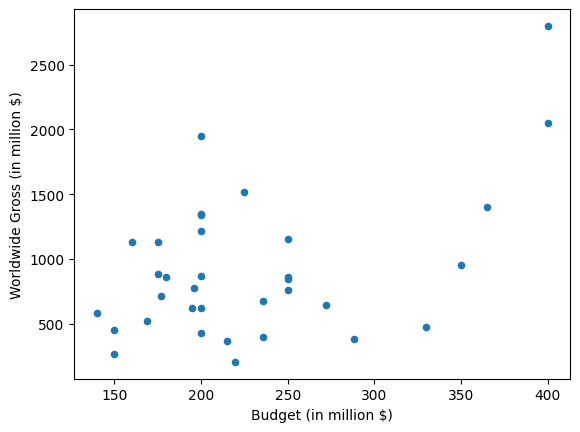

In [25]:
# Interpretando esse enunciado como pedindo essa relação (gráfico)
mv.plot.scatter(x="Budget (in million $)", y="Worldwide Gross (in million $)")

Qual foi a média de Rotten Tomatoes - Audience para os filmes lançados antes de 2010?

In [26]:
print(mv[mv["Release Date (DD-MM-YYYY)"] < "2010-01-01"]["Rotten Tomatoes - Audience (scored out of 100%)"].mean(skipna=True))

80.0


Quantos filmes no dataset possuem dois diretores listados?

In [27]:
print(len(mv[(mv["Director (1)"].isna() == False) & (mv["Director (2)"].isna() == False)]))

5
